# 02 — Exploratory Data Analysis

**Purpose.** This notebook is not a tour of the dataset. It answers five questions whose
answers determine how the rest of the platform is built:

| # | Question | Decides |
|---|---|---|
| 1 | What counts as "delayed"? | The label definition in `04_gold` |
| 2 | How imbalanced is the target? | Which metric we optimise and report |
| 3 | Does delay have temporal structure? | The calendar features in `03_silver`, and the train/test split strategy |
| 4 | How much does `dep_delay` dominate? | Whether the two-model architecture is justified or theatre |
| 5 | What is the cardinality of the categoricals? | One-hot vs target encoding in `04_gold` |

Every decision reached here is restated in the summary at the bottom, and each one is
traceable to a chart above it.

**Reads:** `silver_flights` (cleaned, enriched). **Writes:** nothing — this notebook is read-only.

In [0]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.functions import col

from src import config, plotting as P

silver = spark.table(config.SILVER)

# The binary label is defined in 04_gold; recreate it here so EDA and training
# agree by construction rather than by coincidence.
scored = silver.filter(col("arrival_delay").isNotNull())
labeled = scored.withColumn(
    "label",
    (col("arrival_delay") >= config.DELAY_THRESHOLD_MINUTES).cast("double"),
)

total_rows = silver.count()
scored_rows = scored.count()
date_lo, date_hi = scored.select(F.min("flight_date"), F.max("flight_date")).first()

print(f"Silver rows              : {total_rows:,}")
print(f"With a recorded arrival  : {scored_rows:,}  ({scored_rows / total_rows:.1%})")
print(f"Cancelled / diverted     : {total_rows - scored_rows:,}")
print(f"Date range               : {date_lo} to {date_hi}")

Silver rows              : 2,520,650
With a recorded arrival  : 2,463,979  (97.8%)
Cancelled / diverted     : 56,671
Date range               : 2019-01-01 to 2023-08-31


---

## 1. What counts as "delayed"?

`arrival_delay` is continuous — minutes early (negative) or late (positive). Turning it
into a binary label throws information away, so the threshold needs a defence rather than
a default. Two things to establish: the *shape* of the distribution, and how sensitive the
positive rate is to where the cut is made.

In [0]:
q = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
pct = scored.select(F.percentile_approx("arrival_delay", q, 10000).alias("p")).first()["p"]
mean_delay = scored.select(F.avg("arrival_delay")).first()[0]

print("arrival_delay percentiles (minutes)")
for label, value in zip(q, pct):
    print(f"  p{int(label * 100):<3} {value:>8.1f}")
print(f"\n  mean {mean_delay:>8.1f}")
print(f"  median {pct[3]:>6.1f}")
print(f"\nMean exceeds median by {mean_delay - pct[3]:.1f} min -> right-skewed, "
      f"a minority of very late flights pulls the average up.")

arrival_delay percentiles (minutes)
  p1      -36.0
  p5      -27.0
  p25     -15.0
  p50      -6.0
  p75       8.0
  p95      77.0
  p99     198.0

  mean      6.0
  median   -6.0

Mean exceeds median by 12.0 min -> right-skewed, a minority of very late flights pulls the average up.


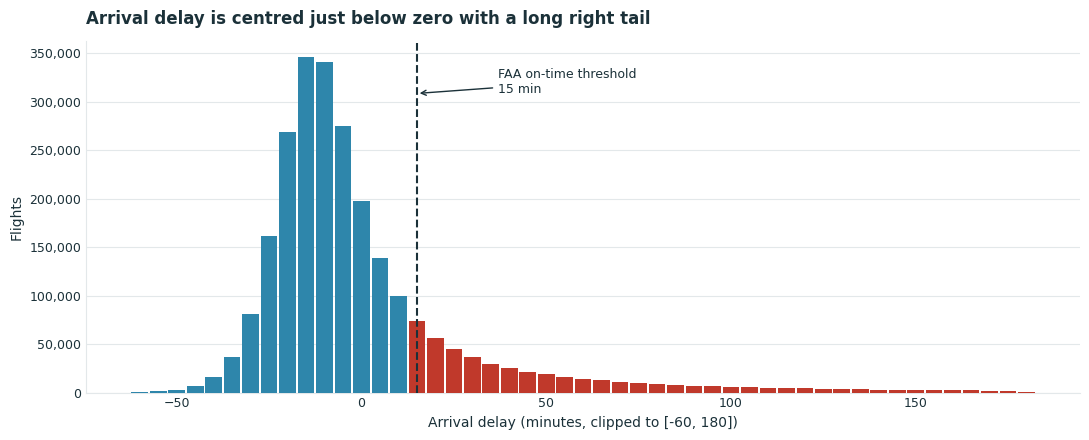

Flights outside [-60, 180] excluded from this chart only: 30,360


In [0]:
# Histogram computed in Spark (bin -> groupBy -> count), never collected raw.
# Serverless has no RDD API, so df.rdd.histogram() is unavailable by design.
BIN = 5
LO, HI = -60, 180

hist = (
    scored.filter(col("arrival_delay").between(LO, HI))
    .withColumn("bin", (F.floor(col("arrival_delay") / BIN) * BIN).cast("int"))
    .groupBy("bin").count()
    .orderBy("bin")
    .toPandas()
)

fig, ax = P.new_axes()
colors = [P.POSITIVE if b >= config.DELAY_THRESHOLD_MINUTES else P.NEGATIVE for b in hist["bin"]]
ax.bar(hist["bin"], hist["count"], width=BIN * 0.9, color=colors, zorder=3)
ax.axvline(config.DELAY_THRESHOLD_MINUTES, color=P.INK, linestyle="--", linewidth=1.5, zorder=4)
ax.annotate(
    f"FAA on-time threshold\n{config.DELAY_THRESHOLD_MINUTES} min",
    xy=(config.DELAY_THRESHOLD_MINUTES, ax.get_ylim()[1] * 0.85),
    xytext=(config.DELAY_THRESHOLD_MINUTES + 22, ax.get_ylim()[1] * 0.85),
    fontsize=9, color=P.INK,
    arrowprops=dict(arrowstyle="->", color=P.INK, linewidth=1),
)
P.style(ax, title="Arrival delay is centred just below zero with a long right tail",
        xlabel="Arrival delay (minutes, clipped to [-60, 180])",
        ylabel="Flights", thousands_y=True)
plt.tight_layout()
plt.show()

print(f"Flights outside [{LO}, {HI}] excluded from this chart only: "
      f"{scored.filter(~col('arrival_delay').between(LO, HI)).count():,}")

**Reading it.** The mode sits slightly *left* of zero — airlines pad scheduled block times,
so the typical flight arrives a few minutes early. The right tail is long and thin: the
rare 3-hour delay is what makes the mean exceed the median.

This shape is why a regression on raw minutes would be dominated by tail error, and why a
classification framing is the more honest fit for the question a traveller actually asks:
*should I expect a problem?*

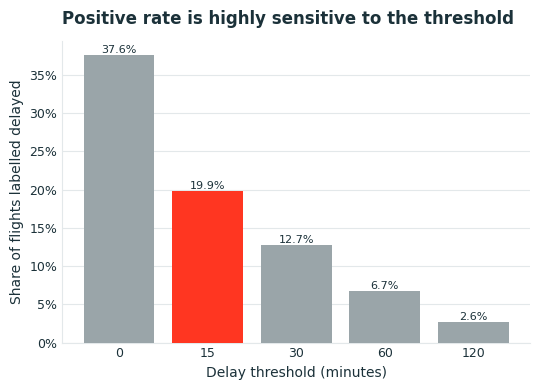

  >=   0 min  ->  37.59% positive
  >=  15 min  ->  19.88% positive
  >=  30 min  ->  12.74% positive
  >=  60 min  ->   6.73% positive
  >= 120 min  ->   2.64% positive


In [0]:
# Where the threshold sits, in one pass over the data.
thresholds = [0, 15, 30, 60, 120]
aggs = [F.sum((col("arrival_delay") >= t).cast("int")).alias(f"t{t}") for t in thresholds]
row = scored.agg(F.count("*").alias("n"), *aggs).first()

rates = [row[f"t{t}"] / row["n"] for t in thresholds]

fig, ax = P.new_axes(P.FIGSIZE_HALF)
bars = ax.bar([str(t) for t in thresholds], rates,
              color=P.highlight_colors(thresholds, lambda t: t == config.DELAY_THRESHOLD_MINUTES),
              zorder=3)
P.annotate_bars(ax, bars, [f"{r:.1%}" for r in rates])
P.style(ax, title="Positive rate is highly sensitive to the threshold",
        xlabel="Delay threshold (minutes)", ylabel="Share of flights labelled delayed",
        percent_y=True)
plt.tight_layout()
plt.show()

for t, r in zip(thresholds, rates):
    print(f"  >= {t:>3} min  ->  {r:6.2%} positive")

**Decision: 15 minutes.**

Not because it produced a convenient class balance, but because it is the US DOT / FAA
definition of an on-time arrival, which means the label matches the number airlines are
publicly measured against and a traveller has already seen. Inheriting an external standard
also removes a degree of freedom I could otherwise have tuned to flatter the model.

The sensitivity chart is the caveat: the positive rate roughly halves between the 15- and
30-minute cuts. Any metric quoted downstream is a metric *at this threshold*, and that
qualifier belongs in the README rather than being left implicit.

**Rejected alternatives.** Regression on raw minutes — the heavy tail dominates squared
error and the output is harder to act on. A three-class scheme (early / on-time / late) —
the middle class has no decision attached to it, so it buys nothing.

---

## 2. How imbalanced is the target, and what does that do to the metric?

This section is the one that determines how success is reported for the rest of the project.

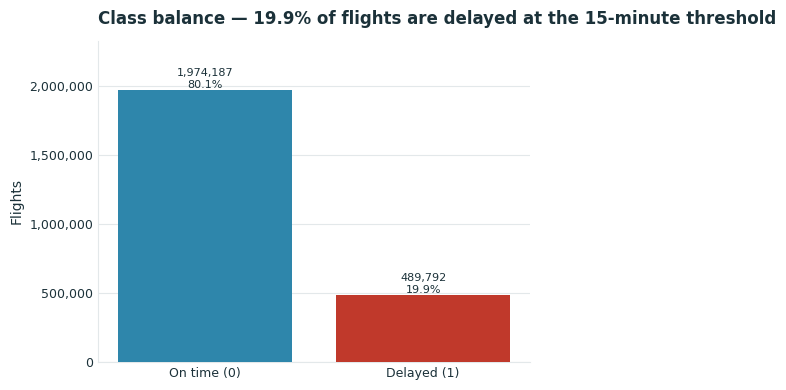

Imbalance ratio: 4.03 negatives per positive


In [0]:
balance = labeled.groupBy("label").count().orderBy("label").toPandas()
neg, pos = int(balance.loc[balance.label == 0, "count"].iloc[0]), int(balance.loc[balance.label == 1, "count"].iloc[0])
pos_rate = pos / (pos + neg)

fig, ax = P.new_axes(P.FIGSIZE_HALF)
bars = ax.bar(["On time (0)", "Delayed (1)"], [neg, pos], color=[P.NEGATIVE, P.POSITIVE], zorder=3)
P.annotate_bars(ax, bars, [f"{neg:,}\n{1 - pos_rate:.1%}", f"{pos:,}\n{pos_rate:.1%}"])
P.style(ax, title=f"Class balance — {pos_rate:.1%} of flights are delayed at the 15-minute threshold",
        ylabel="Flights", thousands_y=True)
ax.set_ylim(0, max(neg, pos) * 1.18)
plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {neg / pos:.2f} negatives per positive")

### Deriving the metric instead of assuming it

The imbalance above is moderate, not extreme — but it is more than enough to make accuracy
a misleading headline. The next cell computes what the two trivial classifiers score, which
is the cheapest possible sanity check and the one most student projects skip.

In [0]:
# Two classifiers that contain no information whatsoever.
always_negative = {
    "accuracy": 1 - pos_rate,
    "precision": 0.0,          # never predicts positive
    "recall": 0.0,
    "f1": 0.0,
}
always_positive = {
    "accuracy": pos_rate,
    "precision": pos_rate,     # every prediction is positive; precision = base rate
    "recall": 1.0,
    "f1": 2 * pos_rate / (1 + pos_rate),
}

print(f"{'':<18}{'accuracy':>10}{'precision':>11}{'recall':>9}{'F1':>8}")
for name, m in [("always 'on time'", always_negative), ("always 'delayed'", always_positive)]:
    print(f"{name:<18}{m['accuracy']:>10.3f}{m['precision']:>11.3f}{m['recall']:>9.3f}{m['f1']:>8.3f}")

print(f"\nA model that predicts 'on time' for every single flight scores "
      f"{always_negative['accuracy']:.1%} accuracy")
print(f"while catching zero of the {pos:,} delayed flights that are the entire point.")
print(f"\nAny real model must therefore beat {always_negative['accuracy']:.3f} accuracy AND "
      f"{always_positive['f1']:.3f} F1 to have earned its complexity.")

                    accuracy  precision   recall      F1
always 'on time'       0.801      0.000    0.000   0.000
always 'delayed'       0.199      0.199    1.000   0.332

A model that predicts 'on time' for every single flight scores 80.1% accuracy
while catching zero of the 489,792 delayed flights that are the entire point.

Any real model must therefore beat 0.801 accuracy AND 0.332 F1 to have earned its complexity.


### The decision

**Primary metric: F1 on the delayed class. Reported alongside PR-AUC. ROC-AUC kept as the
tuning objective. Accuracy reported but never headlined.**

The reasoning, in order:

**Accuracy is disqualified** by the cell above — the do-nothing classifier already scores
in the eighties. Any accuracy figure I quote would be measuring the base rate, not the model.

**F1 is the primary metric** because both error types are real and neither dominates. This
is a two-sided cost problem:

| Error | What it means to the traveller | Cost |
|---|---|---|
| False negative — predicted on time, arrived late | No warning; missed connection, no rebooking | High, and unrecoverable |
| False positive — predicted late, arrived on time | Unnecessary anxiety, possibly a needless rebooking fee | Real, but recoverable |

Because false negatives are worse but false positives are not free, optimising recall alone
(trivially 1.0 — see the always-positive row) or precision alone is wrong. F1's harmonic
mean penalises the lopsided solutions that arithmetic averaging would let through.

**PR-AUC alongside it** because precision-recall curves are the honest view under imbalance:
they ignore true negatives, which are the abundant class and which ROC curves let inflate
the picture.

**ROC-AUC as the tuning objective** because it is threshold-independent, which is what you
want while searching hyperparameters — it measures whether the model *ranks* risky flights
above safe ones, before any decision threshold is chosen. The threshold is a separate,
later decision.

**If the deployment context were known**, F<sub>β</sub> with β > 1 would be the better
choice — it weights recall above precision in proportion to how much worse a missed delay
is than a false alarm. Left as F1 (β = 1) because that weighting is a product decision, not
a modelling one, and I would rather state the assumption than bury it.

**Consequence for `05_train`:** the threshold that maximises F1 is almost never 0.5 under
imbalance. It has to be selected on the validation split and then applied — unchanged — to
the test split.

---

## 3. Does delay have temporal structure?

If it does, the calendar features in `03_silver` are earning their place and a random
train/test split is unsafe.

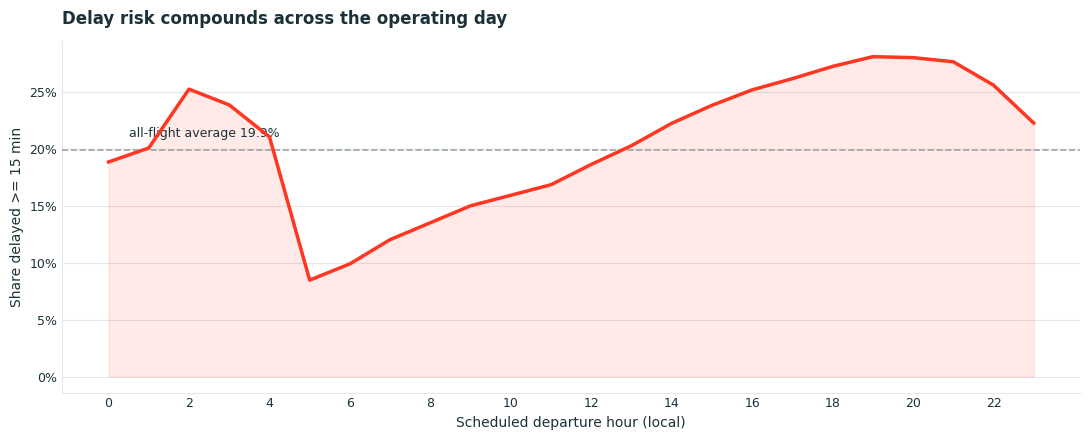

Lowest risk hour : 05:00 -> 8.5%
Highest risk hour: 19:00 -> 28.1%
Spread          : 19.6% (3.3x)


In [0]:
by_hour = (
    labeled.filter(col("dep_hour").isNotNull())
    .groupBy("dep_hour")
    .agg(F.avg("label").alias("delay_rate"), F.count("*").alias("flights"))
    .orderBy("dep_hour")
    .toPandas()
)

fig, ax = P.new_axes()
ax.plot(by_hour["dep_hour"], by_hour["delay_rate"], color=P.ACCENT, linewidth=2.5, zorder=4)
ax.fill_between(by_hour["dep_hour"], by_hour["delay_rate"], color=P.ACCENT, alpha=0.10, zorder=3)
ax.axhline(pos_rate, color=P.MUTED, linestyle="--", linewidth=1.2, zorder=3)
ax.annotate(f"all-flight average {pos_rate:.1%}", xy=(0.5, pos_rate),
            xytext=(0.5, pos_rate * 1.06), fontsize=9, color=P.INK)
P.style(ax, title="Delay risk compounds across the operating day",
        xlabel="Scheduled departure hour (local)", ylabel="Share delayed >= 15 min",
        percent_y=True)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

best = by_hour.loc[by_hour["delay_rate"].idxmin()]
worst = by_hour.loc[by_hour["delay_rate"].idxmax()]
print(f"Lowest risk hour : {int(best.dep_hour):02d}:00 -> {best.delay_rate:.1%}")
print(f"Highest risk hour: {int(worst.dep_hour):02d}:00 -> {worst.delay_rate:.1%}")
print(f"Spread          : {worst.delay_rate - best.delay_rate:.1%} "
      f"({worst.delay_rate / best.delay_rate:.1f}x)")

**Reading it.** This is the most important chart in the notebook. The curve is monotonic
through the operating day: early-morning departures leave on aircraft that have been parked
overnight, and every hour after that inherits the accumulated slippage of the flights before it.

Two consequences, both structural:

1. **`dep_hour` is a real feature, not calendar noise.** The spread between the best and
   worst hour is on the order of the base rate itself.
2. **A random train/test split leaks.** Delays cascade *within a day*, so a random split puts
   the 07:00 departure in train and the 14:00 departure it delayed in test. The model then
   gets credit for information it would not have at prediction time. `05_train` therefore
   splits on time, not at random — train on earlier years, test on the most recent.

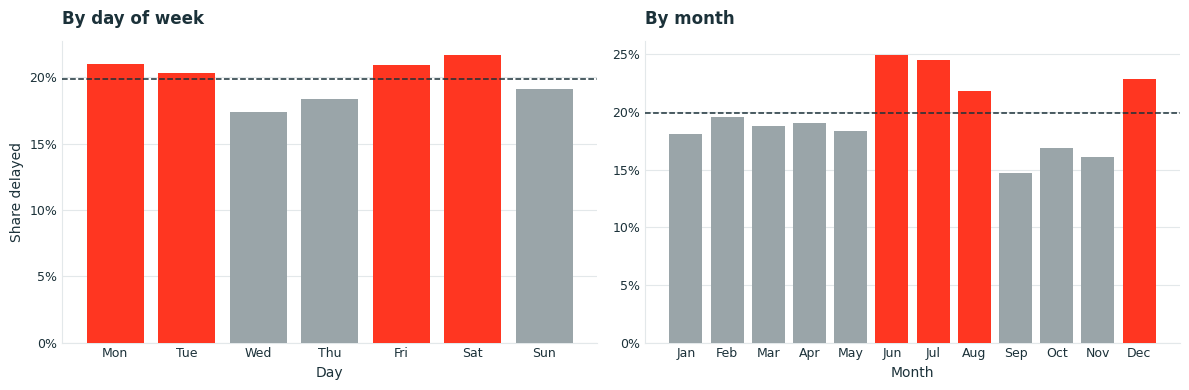

Above-average bars are accented. Dashed line is the all-flight base rate.


In [0]:
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

by_dow = (labeled.groupBy("day_of_week").agg(F.avg("label").alias("rate"))
          .orderBy("day_of_week").toPandas())
by_month = (labeled.groupBy("flight_month").agg(F.avg("label").alias("rate"))
            .orderBy("flight_month").toPandas())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, frame, labels, title, xlabel in [
    (axes[0], by_dow, DOW, "By day of week", "Day"),
    (axes[1], by_month, MONTHS, "By month", "Month"),
]:
    vals = frame["rate"].to_numpy()
    ax.bar(range(len(vals)), vals,
           color=P.highlight_colors(vals, lambda v, m=vals.mean(): v > m), zorder=3)
    ax.axhline(pos_rate, color=P.INK, linestyle="--", linewidth=1.1, zorder=4)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(labels[:len(vals)], fontsize=8)
    P.style(ax, title=title, xlabel=xlabel,
            ylabel="Share delayed" if ax is axes[0] else None, percent_y=True)
plt.tight_layout()
plt.show()

print("Above-average bars are accented. Dashed line is the all-flight base rate.")

**Reading it.** Seasonality is the stronger of the two signals — summer thunderstorm season
and the winter holidays both sit clearly above the base rate, while the shoulder months sit
below it. Day-of-week variation is milder but non-flat, which is enough to keep the feature.

This is the empirical justification for `season`, `flight_month`, and `quarter` existing in
the feature set. They are not there because a calendar decomposition is standard practice.

### The 2020 exclusion

`03_silver` drops 2020 entirely. That is a large, deliberate deletion, so it needs the
evidence behind it — which has to come from Bronze, since Silver has already applied the filter.

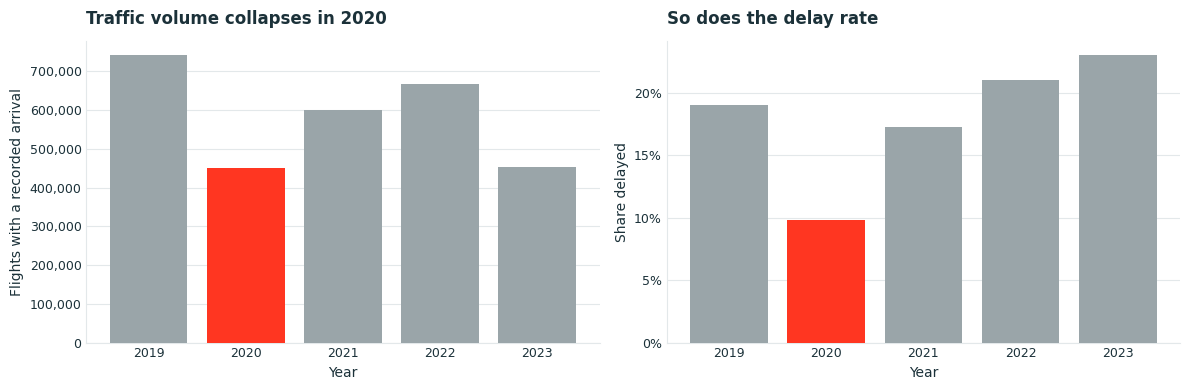

yr,rate,flights
2019,0.1903432979021582,742096
2020,0.09797409203175471,449823
2021,0.17243696526148516,599709
2022,0.2103566994778072,667761
2023,0.23031691434884125,454413


In [0]:
# Bronze retains 2020. Column names are raw Kaggle headers here, so probe defensively.
bronze = spark.table(config.BRONZE)
raw_date = next((c for c in bronze.columns if c.upper() in {"FL_DATE", "FLIGHTDATE"}), None)
raw_delay = next((c for c in bronze.columns if c.upper() in {"ARR_DELAY", "ARRDELAY"}), None)

if raw_date and raw_delay:
    by_year = (
        bronze.filter(col(raw_delay).isNotNull())
        .withColumn("yr", F.year(F.to_date(col(raw_date))))
        .groupBy("yr")
        .agg(F.avg((col(raw_delay) >= config.DELAY_THRESHOLD_MINUTES).cast("double")).alias("rate"),
             F.count("*").alias("flights"))
        .orderBy("yr").toPandas()
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, ycol, title, ylab, pct in [
        (axes[0], "flights", "Traffic volume collapses in 2020", "Flights with a recorded arrival", False),
        (axes[1], "rate", "So does the delay rate", "Share delayed", True),
    ]:
        vals = by_year[ycol].to_numpy()
        ax.bar(by_year["yr"].astype(str), vals,
               color=P.highlight_colors(by_year["yr"], lambda y: y == 2020), zorder=3)
        P.style(ax, title=title, xlabel="Year", ylabel=ylab,
                percent_y=pct, thousands_y=not pct)
    plt.tight_layout()
    plt.show()

    display(by_year)
else:
    print("Raw date/delay columns not found in Bronze — skipping. "
          f"Available: {bronze.columns[:12]}")

**Reading it.** 2020 is not a noisy year, it is a different generating process. Traffic
collapses and the delay rate falls with it — near-empty airports do not produce congestion
delays, and the causal chain the model is meant to learn simply is not operating.

**Decision: drop 2020 rather than flag it.** A `covid_year` indicator would let the model
learn "2020 → predict on time," which generalises to precisely nothing. The cost is the
rows; the benefit is that every remaining row was generated by the system we are actually
modelling.

---

## 4. How much does `dep_delay` dominate?

The two-model architecture — one pre-departure variant without `dep_delay`, one in-flight
variant with it — is the central design claim of this project. If `dep_delay` turns out to
be an ordinary feature, the architecture is unnecessary complexity. This section tests that.

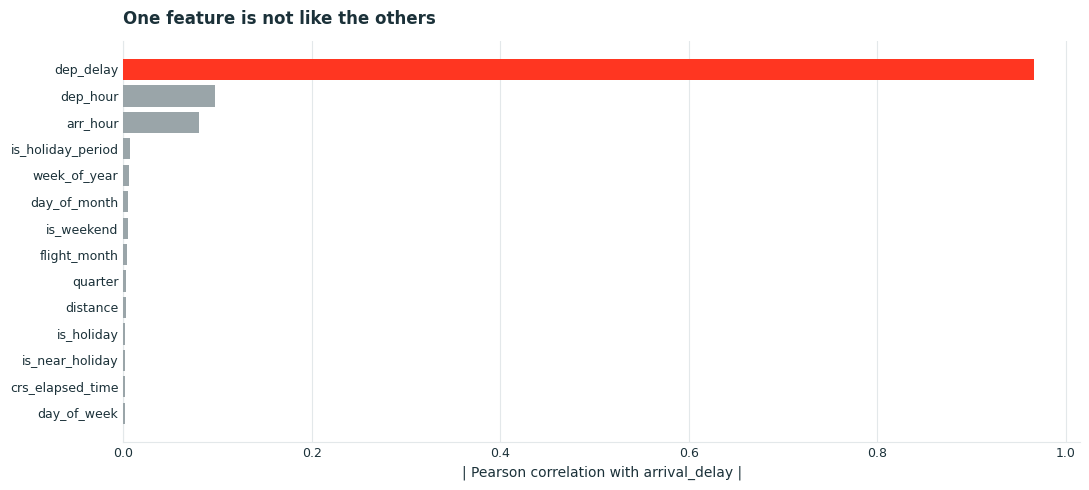

Strongest : dep_delay            r = 0.967
Next      : dep_hour             r = 0.097

dep_delay is 9.9x the correlation of the next feature.


In [0]:
numeric_features = [
    "dep_delay", "crs_elapsed_time", "distance", "dep_hour", "arr_hour",
    "flight_month", "day_of_week", "week_of_year", "day_of_month", "quarter",
    "is_weekend", "is_holiday", "is_near_holiday", "is_holiday_period",
]
available = [c for c in numeric_features if c in labeled.columns]

# All correlations in a single pass.
corr_row = labeled.agg(
    *[F.corr(col(c).cast("double"), col("arrival_delay")).alias(c) for c in available]
).first().asDict()

corrs = sorted(
    ((k, abs(v)) for k, v in corr_row.items() if v is not None),
    key=lambda kv: kv[1], reverse=True,
)
names = [k for k, _ in corrs]
values = [v for _, v in corrs]

fig, ax = P.new_axes((11, 5))
bars = ax.barh(names[::-1], values[::-1],
               color=P.highlight_colors(names[::-1], lambda n: n == "dep_delay"), zorder=3)
P.style(ax, title="One feature is not like the others",
        xlabel="| Pearson correlation with arrival_delay |")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=P.GRID, linewidth=0.8)
plt.tight_layout()
plt.show()

top = corrs[0]
runner = corrs[1]
print(f"Strongest : {top[0]:<20} r = {top[1]:.3f}")
print(f"Next      : {runner[0]:<20} r = {runner[1]:.3f}")
print(f"\n{top[0]} is {top[1] / runner[1]:.1f}x the correlation of the next feature.")

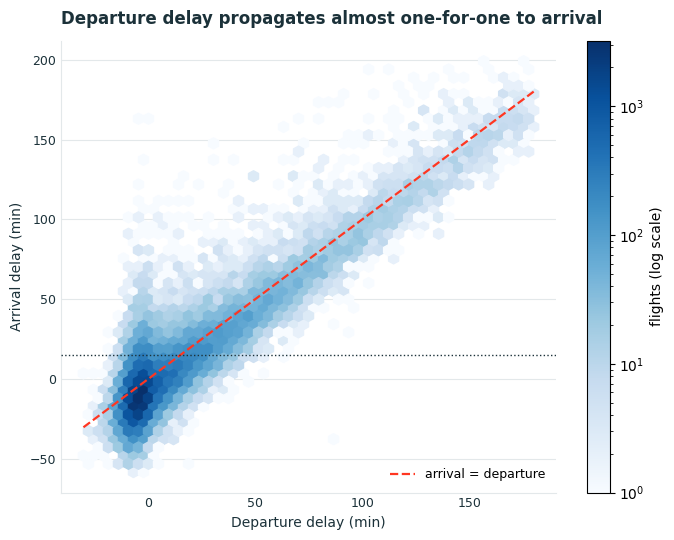

Sampled 48,649 flights for density estimation.


In [0]:
# Density of the dep_delay -> arrival_delay relationship, on a sample.
sample = (
    labeled.filter(col("dep_delay").between(-30, 180) & col("arrival_delay").between(-60, 200))
    .select("dep_delay", "arrival_delay")
    .sample(fraction=0.02, seed=config.RANDOM_SEED)
    .limit(60000)
    .toPandas()
)

fig, ax = P.new_axes((7, 5.5))
hb = ax.hexbin(sample["dep_delay"], sample["arrival_delay"],
               gridsize=45, cmap="Blues", bins="log", mincnt=1, zorder=3)
lims = np.array([-30, 180])
ax.plot(lims, lims, color=P.ACCENT, linewidth=1.6, linestyle="--", zorder=4,
        label="arrival = departure")
ax.axhline(config.DELAY_THRESHOLD_MINUTES, color=P.INK, linewidth=1, linestyle=":", zorder=4)
ax.legend(frameon=False, fontsize=9, loc="lower right")
P.style(ax, title="Departure delay propagates almost one-for-one to arrival",
        xlabel="Departure delay (min)", ylabel="Arrival delay (min)")
fig.colorbar(hb, ax=ax, label="flights (log scale)")
plt.tight_layout()
plt.show()

print(f"Sampled {len(sample):,} flights for density estimation.")

## 5. Where does delay actually come from?

Section 4 showed `dep_delay` dominates. This section asks *why* a flight left late in
the first place, because that determines which features are worth building next.

Bronze carries the BTS cause breakdown — `DELAY_DUE_CARRIER`, `DELAY_DUE_WEATHER`,
`DELAY_DUE_NAS`, `DELAY_DUE_SECURITY`, `DELAY_DUE_LATE_AIRCRAFT`. Silver drops them
deliberately: they are recorded *after* arrival, so using them as features would be
target leakage of the most direct kind. They are read here from Bronze, for analysis
only, and nothing downstream consumes them.

**What they are for.** Every candidate feature and every external data source addresses
some subset of these causes, and each one has a ceiling equal to the share of delay it
could possibly explain. Measuring those shares first turns "should we add a weather API?"
from a guess into an arithmetic question. It is also the cheapest analysis in the project:
the columns are already there.

Two caveats worth stating before reading the numbers:

- The cause columns are populated only for flights reportable as delayed (arrival delay
  of 15 minutes or more). Shares below are therefore shares *of delay*, not of all flights.
- **Weather is undercounted by construction.** BTS books only extreme weather that
  prevented operation under `WEATHER`; weather that congests the airspace system is booked
  under `NAS`. The true weather-attributable share sits somewhere between the `WEATHER`
  bar and `WEATHER + NAS`, and a README that quotes the `WEATHER` bar alone as "the weather
  effect" is understating it.


In [0]:
CAUSE_COLS = {
    "DELAY_DUE_CARRIER": "Carrier",
    "DELAY_DUE_WEATHER": "Weather (extreme)",
    "DELAY_DUE_NAS": "NAS (airspace/ATC)",
    "DELAY_DUE_SECURITY": "Security",
    "DELAY_DUE_LATE_AIRCRAFT": "Late aircraft",
}

bronze_raw = spark.table(config.BRONZE)
present = {c: label for c, label in CAUSE_COLS.items() if c in bronze_raw.columns}
missing = sorted(set(CAUSE_COLS) - set(present))

if not present:
    print("No BTS cause columns in Bronze — skipping section 5.")
    print(f"Available: {bronze_raw.columns}")
    cause_df = None
else:
    if missing:
        print(f"Not present, excluded from the decomposition: {missing}")

    # Match the modelling population: 2020 excluded, arrivals recorded, delayed only.
    delayed = (
        bronze_raw
        .withColumn("yr", F.year(F.to_date(col("FL_DATE"))))
        .filter(col("yr") != 2020)
        .filter(col("ARR_DELAY").isNotNull())
        .filter(col("ARR_DELAY") >= config.DELAY_THRESHOLD_MINUTES)
    )

    agg = delayed.agg(
        F.count("*").alias("delayed_flights"),
        F.sum("ARR_DELAY").alias("total_delay_minutes"),
        *[F.sum(F.coalesce(col(c), F.lit(0.0))).alias(f"min_{c}") for c in present],
        *[F.sum((F.coalesce(col(c), F.lit(0.0)) > 0).cast("int")).alias(f"cnt_{c}")
          for c in present],
    ).first()

    delayed_flights = agg["delayed_flights"]
    attributed = sum(agg[f"min_{c}"] for c in present)

    cause_df = pd.DataFrame([
        {
            "cause": present[c],
            "delay_minutes": agg[f"min_{c}"],
            "share_of_delay_minutes": agg[f"min_{c}"] / attributed,
            "flights_affected": agg[f"cnt_{c}"],
            "share_of_delayed_flights": agg[f"cnt_{c}"] / delayed_flights,
        }
        for c in present
    ]).sort_values("share_of_delay_minutes", ascending=False).reset_index(drop=True)

    display(cause_df)
    print(f"Delayed flights (>= {config.DELAY_THRESHOLD_MINUTES} min, 2020 excluded): "
          f"{delayed_flights:,}")
    print(f"Total delay minutes    : {agg['total_delay_minutes']:,.0f}")
    print(f"Attributed to a cause  : {attributed:,.0f} "
          f"({attributed / agg['total_delay_minutes']:.1%})")
    print("\nShares below are of attributed minutes, so they sum to 100%.")


cause,delay_minutes,share_of_delay_minutes,flights_affected,share_of_delayed_flights
Late aircraft,1.2809175E7,0.38448520583635104,243987,0.49814411015288124
Carrier,1.2070046E7,0.362299220735467,274975,0.5614117829609303
NAS (airspace/ATC),6428215.0,0.19295181519772503,233703,0.4771474421795374
Weather (extreme),1936702.0,0.05813280458059732,28572,0.05833496667973344
Security,70993.0,0.002130953649859579,2527,0.005159332941330197


Delayed flights (>= 15 min, 2020 excluded): 489,792
Total delay minutes    : 33,315,131
Attributed to a cause  : 33,315,131 (100.0%)

Shares below are of attributed minutes, so they sum to 100%.


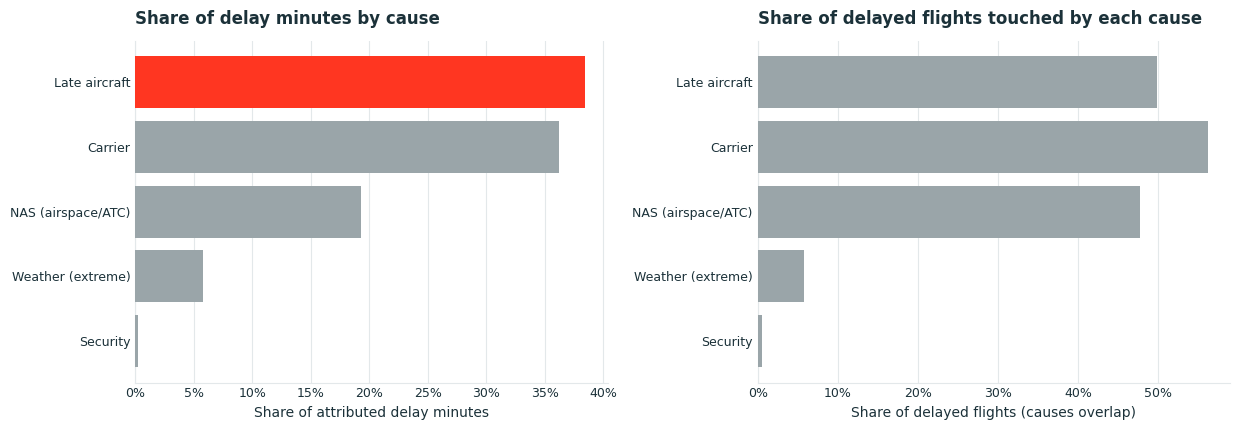

Largest single bucket: Late aircraft at 38.4% of delay minutes, touching 49.8% of delayed flights.

The two panels answer different questions. Left: if this cause vanished,
how many minutes disappear. Right: how many flights it touches at all.
A cause can be common but mild, or rare but severe, and the gap between
the panels is where that shows.


In [0]:
if cause_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

    top = cause_df.iloc[0]["cause"]
    bars = axes[0].barh(
        cause_df["cause"][::-1], cause_df["share_of_delay_minutes"][::-1],
        color=P.highlight_colors(cause_df["cause"][::-1], lambda c: c == top), zorder=3,
    )
    P.style(axes[0], title="Share of delay minutes by cause",
            xlabel="Share of attributed delay minutes")
    axes[0].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    axes[0].grid(axis="y", visible=False)
    axes[0].grid(axis="x", color=P.GRID, linewidth=0.8)

    axes[1].barh(
        cause_df["cause"][::-1], cause_df["share_of_delayed_flights"][::-1],
        color=P.MUTED, zorder=3,
    )
    P.style(axes[1], title="Share of delayed flights touched by each cause",
            xlabel="Share of delayed flights (causes overlap)")
    axes[1].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    axes[1].grid(axis="y", visible=False)
    axes[1].grid(axis="x", color=P.GRID, linewidth=0.8)

    plt.tight_layout()
    plt.show()

    lead = cause_df.iloc[0]
    print(f"Largest single bucket: {lead['cause']} at "
          f"{lead['share_of_delay_minutes']:.1%} of delay minutes, touching "
          f"{lead['share_of_delayed_flights']:.1%} of delayed flights.")
    print("\nThe two panels answer different questions. Left: if this cause vanished,")
    print("how many minutes disappear. Right: how many flights it touches at all.")
    print("A cause can be common but mild, or rare but severe, and the gap between")
    print("the panels is where that shows.")


### Late aircraft is a cascade, and cascades are predictable from a schedule

`LATE_AIRCRAFT` is not an independent cause. It means the inbound aircraft arrived late,
so this flight left late — it is delay *propagating* through an airframe's day. That has a
direct consequence for feature engineering: propagation compounds with time of day, so its
share should grow from morning to evening. If it does, the intraday cascade section 3 found
in the raw delay rate has a mechanism behind it rather than being a pattern in a chart.

It also explains why the pre-departure model stalls around 0.61. The features it has —
airline, route, month, day of week, hour — are *static* attributes of a scheduled flight.
Nothing in them says how the operating day is actually going. Congestion features derived
from the published schedule would, and they are leak-free precisely because schedules are
known months in advance.


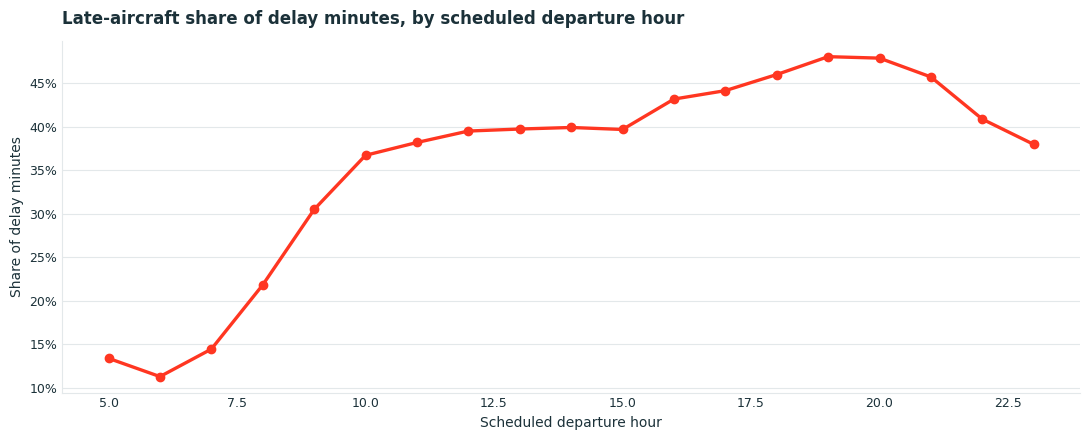

Before 09:00 : 15.2% of delay minutes are late-aircraft
After  18:00 : 44.4%
Change across the operating day: +29.2%

A rising line is the cascade made visible: the first bank of the morning has
no inbound delay to inherit, and every bank after it does. This is the single
clearest argument for congestion features, and it costs no external data.


In [0]:
if cause_df is not None and "DELAY_DUE_LATE_AIRCRAFT" in present:
    by_hour = (
        delayed
        .withColumn("dep_hour", F.floor(col("CRS_DEP_TIME") / 100))
        .filter(col("dep_hour").between(5, 23))
        .groupBy("dep_hour")
        .agg(
            F.sum(F.coalesce(col("DELAY_DUE_LATE_AIRCRAFT"), F.lit(0.0))).alias("late_ac"),
            F.sum("ARR_DELAY").alias("total"),
            F.count("*").alias("flights"),
        )
        .withColumn("late_ac_share", col("late_ac") / col("total"))
        .orderBy("dep_hour")
        .toPandas()
    )

    fig, ax = P.new_axes(P.FIGSIZE_WIDE)
    ax.plot(by_hour["dep_hour"], by_hour["late_ac_share"], color=P.ACCENT,
            marker="o", markersize=6, linewidth=2.4)
    P.style(ax, title="Late-aircraft share of delay minutes, by scheduled departure hour",
            xlabel="Scheduled departure hour", ylabel="Share of delay minutes",
            percent_y=True)
    plt.tight_layout()
    plt.show()

    early = by_hour[by_hour["dep_hour"] <= 8]["late_ac_share"].mean()
    late = by_hour[by_hour["dep_hour"] >= 18]["late_ac_share"].mean()
    print(f"Before 09:00 : {early:.1%} of delay minutes are late-aircraft")
    print(f"After  18:00 : {late:.1%}")
    print(f"Change across the operating day: {late - early:+.1%}")
    print()
    print("A rising line is the cascade made visible: the first bank of the morning has")
    print("no inbound delay to inherit, and every bank after it does. This is the single")
    print("clearest argument for congestion features, and it costs no external data.")


**Decision: build schedule-derived congestion features before adding any external source.**

The decomposition sizes the options rather than ranking them by intuition:

- **Late aircraft** is propagation. Nothing external is needed to model it — the published
  schedule already contains departures per origin-hour, bank density, and each flight's
  position in the operating day. These are leak-free by construction and cost one window
  function each. `TAIL_NUM` is absent from this dataset, so true aircraft-rotation chaining
  is not available; position-in-day is the closest usable proxy.
- **NAS** is airspace congestion, which the same congestion features partly proxy.
- **Weather** is the only bucket that genuinely needs outside data, and its ceiling is the
  `WEATHER` share plus whatever part of `NAS` is weather-driven. Worth revisiting *after*
  the congestion features, and worth stating carefully: a pre-departure model would have a
  forecast at inference time, not the observation, so training on observed weather measures
  an upper bound rather than deployable performance.
- **Carrier** is internal airline operations, largely invisible in this dataset.
- **Security** is negligible and is not worth a feature.

The order follows the arithmetic: the largest bucket is addressable with data already in
hand, so that work comes first.


**Reading it.** The mass sits along the identity line, slightly below it — aircraft recover
a little time in the air, but a flight that leaves late arrives late. `dep_delay` is not a
strong feature; it is very nearly the answer.

**Which is exactly the problem.** `dep_delay` does not exist until the aircraft has already
pushed back. A model that uses it is accurate and useless for the decision a traveller is
actually making — whether to book this flight, whether the connection is safe, whether to
rebook. By the time the feature exists, the decision has passed.

**Decision: two models over the same feature store, selected by flight phase.**

| Variant | Sees `dep_delay` | Available | Answers |
|---|---|---|---|
| Pre-departure | No | At booking, and up to pushback | "Is this flight a risk?" |
| In-flight | Yes | After pushback | "Given we left 20 late, do we arrive late?" |

The pre-departure model deliberately gives up the strongest predictor in the dataset in
order to exist at the moment the decision is made. The gap between the two AUCs in `05_train`
is the measurable price of that constraint — and quantifying it is more interesting than
either model alone.

**Rejected alternative.** One model with `dep_delay` imputed to zero when unknown. It would
train on a relationship that does not hold at inference time and quietly mis-rank every
pre-departure flight.

---

## 6. Cardinality — how should the categoricals be encoded?

In [0]:
card = labeled.agg(
    F.countDistinct("airline_code").alias("airlines"),
    F.countDistinct("origin_airport_code").alias("origins"),
    F.countDistinct("destination_airport_code").alias("destinations"),
    F.countDistinct(F.concat_ws("-", "origin_airport_code", "destination_airport_code")).alias("routes"),
).first().asDict()

for k, v in card.items():
    print(f"  {k:<14} {v:>6,} distinct")

ohe_width = card["airlines"] + card["origins"] + card["destinations"]
print(f"\nOne-hot width if airline + origin + destination are encoded: ~{ohe_width:,} columns")
print(f"One-hot width if route were encoded as a single feature:      ~{card['routes']:,} columns")

  airlines           18 distinct
  origins           379 distinct
  destinations      379 distinct
  routes          7,675 distinct

One-hot width if airline + origin + destination are encoded: ~776 columns
One-hot width if route were encoded as a single feature:      ~7,675 columns


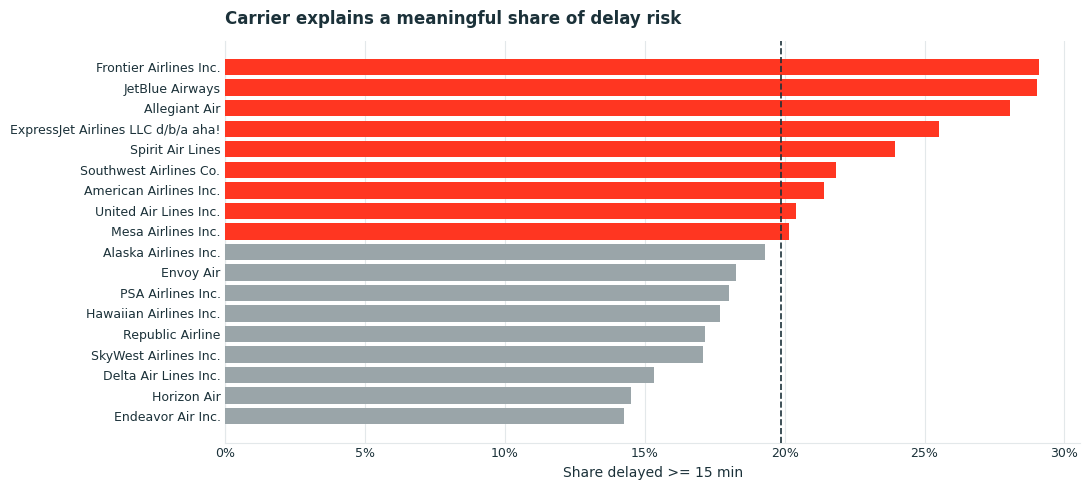

Best-to-worst carrier spread: 14.8% (2.0x)


In [0]:
by_airline = (
    labeled.groupBy("airline_name")
    .agg(F.avg("label").alias("rate"), F.count("*").alias("flights"))
    .filter(col("flights") > 10000)
    .orderBy(F.desc("rate"))
    .toPandas()
)

fig, ax = P.new_axes((11, 5))
vals = by_airline["rate"].to_numpy()
ax.barh(by_airline["airline_name"][::-1], vals[::-1],
        color=P.highlight_colors(vals[::-1], lambda v: v > pos_rate), zorder=3)
ax.axvline(pos_rate, color=P.INK, linestyle="--", linewidth=1.2, zorder=4)
P.style(ax, title="Carrier explains a meaningful share of delay risk",
        xlabel="Share delayed >= 15 min")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=P.GRID, linewidth=0.8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()

spread = by_airline["rate"].max() - by_airline["rate"].min()
print(f"Best-to-worst carrier spread: {spread:.1%} "
      f"({by_airline['rate'].max() / by_airline['rate'].min():.1f}x)")

**Decision: one-hot encode airline, origin, and destination. Do not encode route.**

Airline and airport cardinality is in the hundreds, which one-hot handles fine inside a
sparse `VectorAssembler` — and sparse one-hot is also why `04_gold` uses
`StandardScaler(withMean=False)`: centring would densify the vector and blow up memory for
no modelling benefit.

Route as a single categorical is a different matter. Thousands of distinct values, most with
few flights, would give the trees a high-cardinality split to overfit on. Origin and
destination are kept separate; the model can learn the interaction if it is there.

**Rejected alternative.** Target encoding for route. Stronger in principle, but it leaks
target information across the train/test boundary unless the encoding is fitted inside a
cross-validation fold — added complexity for a gain not demonstrated here.

---

## 7. Do the engineered holiday features actually separate?

`03_silver` adds three holiday flags via unit-tested helpers. Engineered features should have
to justify themselves, and the honest answer here is that these do not. The section is kept
rather than deleted because a negative result that changes what the README may claim is worth
as much as a positive one.

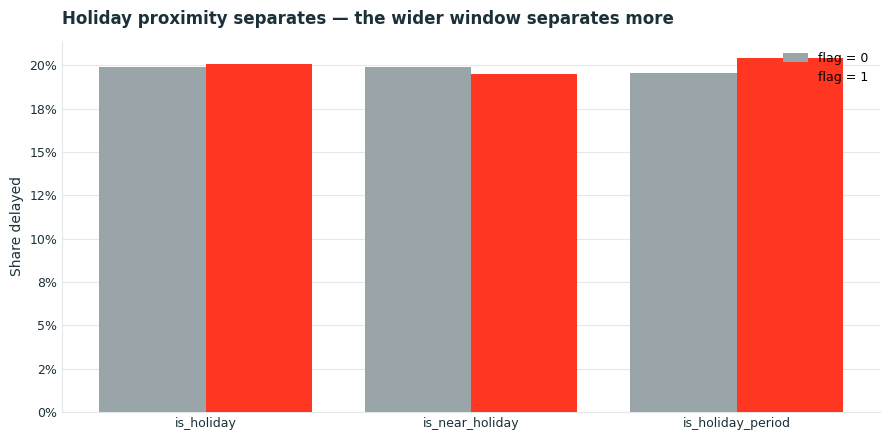

feature                  off      on     lift      n (on)
is_holiday            19.87%  20.08%   +0.21%      77,564
is_near_holiday       19.91%  19.49%   -0.42%     209,955
is_holiday_period     19.53%  20.40%   +0.87%     988,003


In [0]:
flags = [f for f in ["is_holiday", "is_near_holiday", "is_holiday_period"] if f in labeled.columns]

rows = []
for f in flags:
    agg = (labeled.groupBy(f).agg(F.avg("label").alias("rate"), F.count("*").alias("n"))
           .orderBy(f).toPandas())
    off = agg.loc[agg[f] == 0, "rate"].iloc[0]
    on = agg.loc[agg[f] == 1, "rate"].iloc[0]
    n_on = int(agg.loc[agg[f] == 1, "n"].iloc[0])
    rows.append((f, off, on, on - off, n_on))

x = np.arange(len(rows))
fig, ax = P.new_axes((9, 4.5))
ax.bar(x - 0.2, [r[1] for r in rows], width=0.4, color=P.MUTED, label="flag = 0", zorder=3)
ax.bar(x + 0.2, [r[2] for r in rows], width=0.4, color=P.ACCENT, label="flag = 1", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in rows], fontsize=9)
ax.legend(frameon=False, fontsize=9)
P.style(ax, title="Holiday proximity separates — the wider window separates more",
        ylabel="Share delayed", percent_y=True)
plt.tight_layout()
plt.show()

print(f"{'feature':<20}{'off':>8}{'on':>8}{'lift':>9}{'n (on)':>12}")
for name, off, on, lift, n_on in rows:
    print(f"{name:<20}{off:>8.2%}{on:>8.2%}{lift:>+9.2%}{n_on:>12,}")

**Reading it — these features do not work.** The engineered flags were supposed to justify
themselves, and on this evidence they do not.

Against a base rate near 20%, the lifts are fractions of a percentage point. `is_holiday`
moves the rate by +0.21pp, which is noise. `is_holiday_period` is the largest at +0.87pp —
about 4% in relative terms, and the only one pointing the intuitive way. And
`is_near_holiday` comes back **negative**: flights within a day of a federal holiday are
*less* likely to be delayed than flights that are not.

That negative sign is worth sitting with rather than explaining away. The most plausible
reading is a volume effect — carriers thin their schedules on the holiday itself and the day
either side, and a thinner schedule cascades less. If so the flag is picking up reduced
congestion, which is a real signal about the wrong thing: it measures how *busy* the day is,
badly, when a direct congestion feature would measure it well. That is the same conclusion
§5 reaches from the delay-cause decomposition, arrived at independently.

`05_train` corroborates this without being told to. Its Stage 1 sweep selects roughly ten
features out of 814, and the top five carry over 90% of the ensemble's importance — the
holiday flags do not survive selection. The pipeline is already discarding them.

**They stay in Silver anyway, and the distinction matters.** Silver is the general cleaned
layer, the flags are cheap and unit-tested, and a future model — cancellations, say, where
holiday scheduling plausibly does matter — reads the same table. What changes is the claim:
these are available features that this model does not use, not features shown to help. The
README must not list them as engineered features that improved anything.

---

## 8. Data quality

In [0]:
check_cols = [c for c in labeled.columns if c not in {"label"}]
null_counts = labeled.select(
    [F.sum(col(c).isNull().cast("int")).alias(c) for c in check_cols]
).first().asDict()

nulls = sorted(((k, v, v / scored_rows) for k, v in null_counts.items() if v > 0),
               key=lambda kv: kv[1], reverse=True)

if nulls:
    print(f"{'column':<28}{'nulls':>12}{'share':>10}")
    for name, n, share in nulls:
        print(f"{name:<28}{n:>12,}{share:>10.3%}")
else:
    print("No nulls in the Silver layer after cleaning.")

print(f"\nCancelled / diverted flights held in Silver and filtered at Gold: "
      f"{total_rows - scored_rows:,} ({(total_rows - scored_rows) / total_rows:.2%})")

No nulls in the Silver layer after cleaning.

Cancelled / diverted flights held in Silver and filtered at Gold: 56,671 (2.25%)


**Decision: keep cancelled and diverted flights in Silver, filter them at Gold.**

They have no `arrival_delay`, so they cannot carry a label and cannot train a model. But
they are real operational events, and dropping them at Silver would make the layer a
model-specific artefact rather than a general cleaned view. Silver stays reusable — a future
cancellation-prediction model reads the same table.

This is the medallion boundary doing its job: Silver is *cleaned*, Gold is *task-specific*.

---

## 9. What this notebook decided

| Question | Evidence | Decision |
|---|---|---|
| Label definition | Threshold sensitivity chart (§1) | Binary at 15 min, the FAA on-time standard; sensitivity disclosed |
| Metric | Trivial-classifier scores (§2) | F1 primary, PR-AUC alongside, ROC-AUC for tuning, accuracy never headlined |
| Decision threshold | Imbalance (§2) | Tune on validation, not 0.5; apply unchanged to test |
| Calendar features | Hour / month / day-of-week separation (§3) | Keep `dep_hour`, `season`, `flight_month`, `quarter`, `day_of_week` |
| Split strategy | Intraday cascade (§3) | Temporal holdout, not random — delays autocorrelate within a day |
| 2020 | Volume and rate collapse (§3) | Drop entirely; do not flag |
| Architecture | `dep_delay` correlation dominance (§4) | Two models, phase-selected |
| Next features | Delay-cause decomposition (§5) | Schedule-derived congestion features before any external API; late aircraft is the largest bucket and needs no new data |
| Encoding | Cardinality counts (§6) | One-hot airline / origin / destination; no route encoding; `withMean=False` |
| Holiday features | Lift table (§7) | Retained in Silver but **not** shown to help: lifts of +0.21pp, −0.42pp, +0.87pp on a ~20% base rate, and the selector in `05_train` drops them. `is_near_holiday` is negative. |
| Cancelled flights | Null analysis (§8) | Retain in Silver, filter at Gold |

Next: `03_silver` applies the cleaning and feature decisions, `04_gold` applies the encoding
decisions, `05_train` applies the metric and split decisions.